# Prompt U-Net Context Experiment

This notebook isolates the impact of **Image Slicing/Resizing (Squished vs Cropped)** on Prompt U-Net's performance. You can quickly hot-swap the model version below to see how different ablations (e.g., v310 vs v312 vs legacy v292) respond to raw crops vs aggressive macroscopic scaling.

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import tensorflow as tf

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from evaluation.p_unet_inference import PromptUNetPredictor

# CPU speedup for inference
if len(tf.config.list_physical_devices('GPU')) == 0:
    tf.keras.mixed_precision.set_global_policy('float32')

# ==================================================
# HOT-SWAP YOUR MODEL VERSION HERE
# ==================================================
model_version = "292"  # Try "310", "311", "312", or "292"
model_path = project_root / f"training/p_unet_{model_version}.keras"
predictor = PromptUNetPredictor(model_path)
print(f"Loaded Prompt U-Net v{model_version} successfully.")

Loaded Prompt U-Net v292 successfully.


In [3]:
loader = DataLoader_npz([str(project_root / "data/test_data/FLARE_2022.npz")], val_size=0.0)

# Pick a patient with a decent sized organ/tumor
pid = list(loader.dataset.keys())[0]  # Just grab the first one
patient_data = loader.dataset[pid]
vol = patient_data["image"]
labels = patient_data["segmentations"][0]

# Let's pick label 1 (e.g. liver/tumor)
binary_mask = (labels == 1).astype(np.float32)

# Find slices with mask
z_indices = np.where(binary_mask.sum(axis=(0,1)) > 50)[0]
support_z = z_indices[len(z_indices)//2]  # Middle slice
query_z   = support_z + 10                # Offset + 10

print(f"Patient: {pid}")
print(f"Support Slice: {support_z}, Query Slice: {query_z}")


Loading NPZ dataset(s)…
Loaded 50 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\FLARE_2022.npz

Final dataset size: 50 patients.

Patient: FLARE_2022_FLARE22_Tr_0001
Support Slice: 207, Query Slice: 217


## Method 1: "Legacy" Global Resized Pipeline

1. Entire 512x512 array is taken.
2. Z-score scaled (+/- 5).
3. Bilinearly squished/resized to 128x128.

In [4]:
def method1_legacy(z_idx):
    img_slice = vol[:, :, z_idx].copy()
    msk_slice = binary_mask[:, :, z_idx].copy()
    
    # 1. Per-slice Z-score
    m = np.mean(img_slice)
    s = np.std(img_slice) + 1e-8
    img_slice = np.clip((img_slice - m) / s, -5.0, 5.0)
        
    # 2. Resize to 128x128
    img_128 = zoom(img_slice, (128/img_slice.shape[0], 128/img_slice.shape[1]), order=1)
    msk_128 = zoom(msk_slice, (128/msk_slice.shape[0], 128/msk_slice.shape[1]), order=0)
    
    return img_128, msk_128

m1_supp_img, m1_supp_msk = method1_legacy(support_z)
m1_query_img, m1_query_msk = method1_legacy(query_z)

## Method 2: "Current" Patch Cropped Pipeline

1. Normalizes the **entire 3D volume**.
2. Extracts a literal, strict 128x128 crop centered on the Support Mask.

In [5]:
def method2_current():
    # 1. 3D Volume Z-score
    m = np.mean(vol)
    s = np.std(vol) + 1e-8
    vol_norm = np.clip((vol - m) / s, -5.0, 5.0)
    
    # Extract 2D slices
    s_img = vol_norm[:, :, support_z]
    s_msk = binary_mask[:, :, support_z]
    q_img = vol_norm[:, :, query_z]
    q_msk = binary_mask[:, :, query_z]
    
    # 2. Calculate Strict 128 Crop centered on Support
    ps = 128
    nonzero = np.argwhere(s_msk > 0)
    if len(nonzero) > 0:
        min_h, min_w = nonzero.min(axis=0)
        max_h, max_w = nonzero.max(axis=0)
        
        h_center = (min_h + max_h) // 2
        w_center = (min_w + max_w) // 2
        
        sh = max(0, min(h_center - ps//2, s_img.shape[0] - ps))
        sw = max(0, min(w_center - ps//2, s_img.shape[1] - ps))
    else:
        sh, sw = 0, 0
        
    # Extract
    def crop(a):
        return a[sh:sh+ps, sw:sw+ps]
        
    return crop(s_img), crop(s_msk), crop(q_img), crop(q_msk)

m2_supp_img, m2_supp_msk, m2_query_img, m2_query_msk = method2_current()

## Prompt U-Net Inference and Comparison

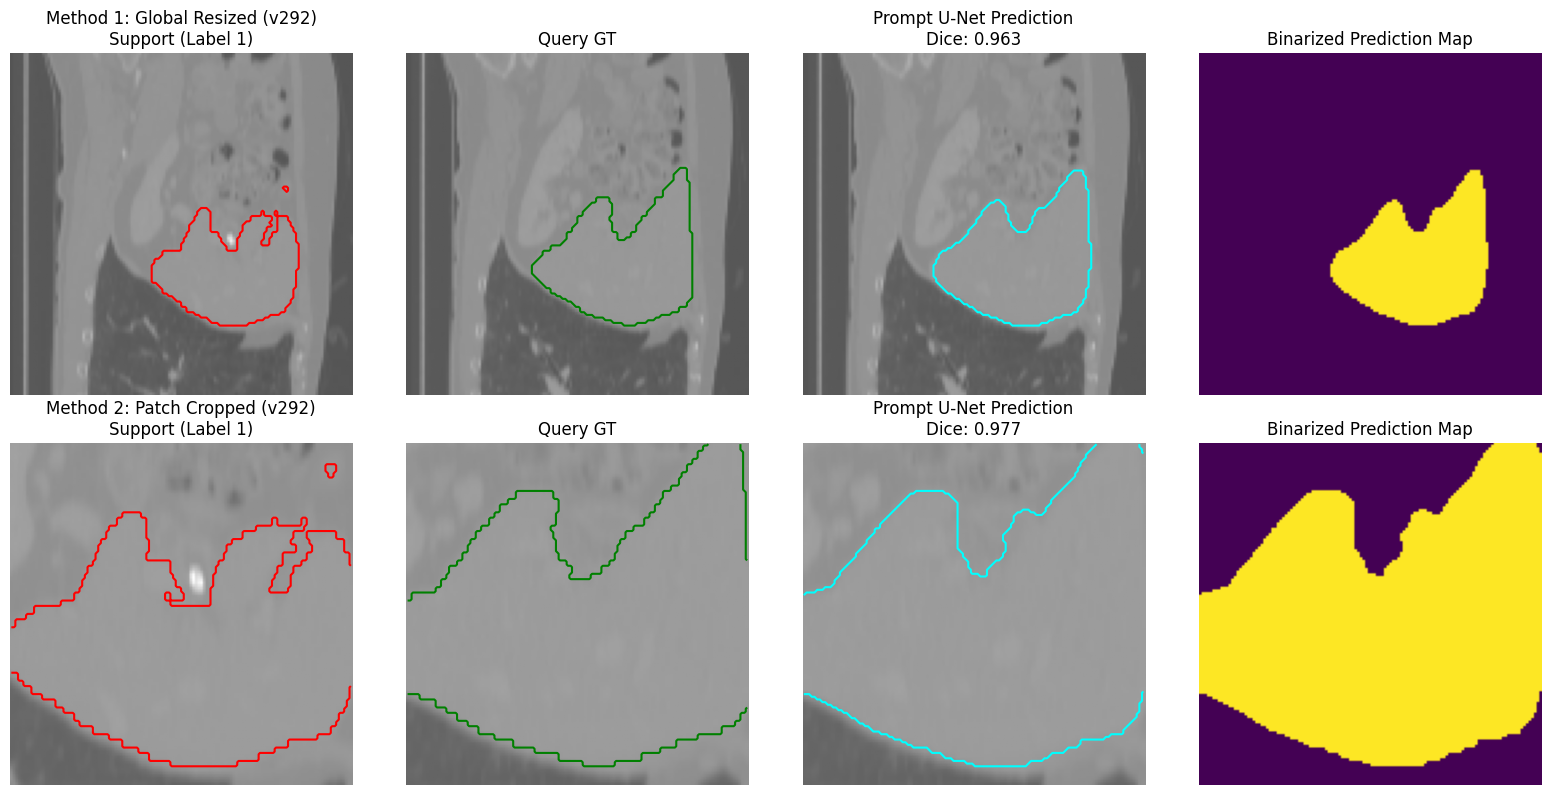

In [6]:
def dice(pred, target):
    pred = (pred > 0.5).astype(float)
    target = (target > 0.5).astype(float)
    inter = (pred * target).sum()
    return (2. * inter) / (pred.sum() + target.sum() + 1e-8)

def run_punet(s_img, s_msk, q_img, q_msk):
    # Prompt U-Net builds its prompt tensor by concatenating [reference_image, reference_mask]
    p_arr = np.stack([s_img, s_msk], axis=-1)  # Shape: (128, 128, 2)
    
    # Predictor wrapper handles standardising to (1, 128, 128, C)
    pred = predictor.predict(q_img, p_arr, threshold=0.5)
    
    score = dice(pred, q_msk)
    return pred, score

# Run both
m1_pred, m1_score = run_punet(m1_supp_img, m1_supp_msk, m1_query_img, m1_query_msk)
m2_pred, m2_score = run_punet(m2_supp_img, m2_supp_msk, m2_query_img, m2_query_msk)

# ── Visualisation ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

def show_row(row_idx, s_img, s_msk, q_img, q_msk, pred, score, title):
    axes[row_idx, 0].imshow(s_img, cmap='gray', vmin=-5, vmax=5)
    axes[row_idx, 0].contour(s_msk, colors='red', levels=[0.5])
    axes[row_idx, 0].set_title(f"{title}\nSupport (Label 1)")
    
    axes[row_idx, 1].imshow(q_img, cmap='gray', vmin=-5, vmax=5)
    axes[row_idx, 1].contour(q_msk, colors='green', levels=[0.5])
    axes[row_idx, 1].set_title("Query GT")
    
    axes[row_idx, 2].imshow(q_img, cmap='gray', vmin=-5, vmax=5)
    axes[row_idx, 2].contour(pred, colors='cyan', levels=[0.5])
    axes[row_idx, 2].set_title(f"Prompt U-Net Prediction\nDice: {score:.3f}")
    
    axes[row_idx, 3].imshow(pred, cmap='viridis')
    axes[row_idx, 3].set_title("Binarized Prediction Map")
    
    for ax in axes[row_idx]:
        ax.axis('off')

show_row(0, m1_supp_img, m1_supp_msk, m1_query_img, m1_query_msk, m1_pred, m1_score, f"Method 1: Global Resized (v{model_version})")
show_row(1, m2_supp_img, m2_supp_msk, m2_query_img, m2_query_msk, m2_pred, m2_score, f"Method 2: Patch Cropped (v{model_version})")

plt.tight_layout()
plt.show()